In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

%matplotlib inline

In [2]:
statistic = pd.read_table("../results/processedData/normalized_mean/ttest_all_statistic.table", delimiter=" ")
pvalue = pd.read_table("../results/processedData/normalized_mean/ttest_all_pvalue.table", delimiter=" ")
query_number = pd.read_table("../results/processedData/normalized_mean/ttest_all_query_number.table", delimiter=" ")
target_number = pd.read_table("../results/processedData/normalized_mean/ttest_all_target_number.table", delimiter=" ")

In [3]:
statistic = statistic.iloc[0:-1]
pvalue = pvalue.iloc[0:-1]
query_number = query_number[0:-1]

In [4]:
statistic = statistic.rename(columns={'Eco1KD_B8':'Eco1KD'})
pvalue = pvalue.rename(columns={'Eco1KD_B8':'Eco1KD'})

In [5]:
# Conventionalized, cvbt, 3OHAHL, EcoKD
l_supercluster_statistic = statistic.loc[statistic.index.str.contains("^L_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
supercluster_statistic = statistic.loc[statistic.index.str.contains("^C_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
ectoderm_statistic = statistic.loc[statistic.index.str.contains("^Ec_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
endoderm_statistic = statistic.loc[statistic.index.str.contains("^En_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
interstitial_statistic = statistic.loc[statistic.index.str.contains("^I_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]

l_supercluster_pvalue = pvalue.loc[pvalue.index.str.contains("^L_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
supercluster_pvalue = pvalue.loc[pvalue.index.str.contains("^C_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
ectoderm_pvalue = pvalue.loc[pvalue.index.str.contains("^Ec_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
endoderm_pvalue = pvalue.loc[pvalue.index.str.contains("^En_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
interstitial_pvalue = pvalue.loc[pvalue.index.str.contains("^I_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]


l_supercluster_query = query_number.loc[query_number.index.str.contains("^L_*")]
supercluster_query = query_number.loc[query_number.index.str.contains("^C_*")]
ectoderm_query = query_number.loc[query_number.index.str.contains("^Ec_*")]
endoderm_query = query_number.loc[query_number.index.str.contains("^En_*")]
interstitial_query = query_number.loc[query_number.index.str.contains("^I_*")]

sliced_targets = target_number[['Conventionalized','Cvbct','3OHC12','Eco1KD_B8']]

In [6]:
ectoderm_statistic

,Conventionalized,Cvbct,3OHC12,Eco1KD
Ec_Head,5,5,3,-3
Ec_BodyCol.SC,0,0,0,0
Ec_Peduncle,-5,4,-1,-2
Ec_Tentacle,7,7,2,-4
Ec_BasalDisk,-4,1,-2,-12


In [7]:
ectoderm_pvalue

,Conventionalized,Cvbct,3OHC12,Eco1KD
Ec_Head,2.444315e-05,7.679688e-05,0.006232,3.044237e-03
Ec_BodyCol.SC,1.000000e+00,1.000000e+00,1.000000,1.000000e+00
Ec_Peduncle,4.032565e-05,3.456964e-04,0.209943,8.250232e-02
Ec_Tentacle,1.192283e-07,1.243383e-07,0.058093,9.025732e-04
Ec_BasalDisk,8.517334e-05,5.431200e-01,0.038599,1.083244e-20


In [8]:
ectoderm_query

,V1
Ec_Head,29
Ec_BodyCol.SC,2
Ec_Peduncle,22
Ec_Tentacle,31
Ec_BasalDisk,80


In [8]:
def plot_heatmap_of_clusterings(statistic:pd.DataFrame,
                                pvalue:pd.DataFrame,
                                query_number:pd.DataFrame,
                                target_number:pd.DataFrame,
                               title:str,
                               yaxis:str,
                               xaxis:str,
                               output_filename:str,
                               size=(14,16),
                               fonts=15,
                               padx=0.05):
    try:
        # set the colormap and centre the colorbar
        class MidpointNormalize(colors.Normalize):
            """Normalise the colorbar."""
            def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
                self.midpoint = midpoint
                colors.Normalize.__init__(self, vmin, vmax, clip)

            def __call__(self, value, clip=None):
                x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
                return np.ma.masked_array(np.interp(value, x, y), np.isnan(value))

        print("[*] Adjusting statistic values to pvalue ...\n[*] Setting values with pval > 0.05 to 0 ...")
        for i in range(statistic.shape[0]):
            for j in range(statistic.shape[1]):
                if pvalue.iloc[i, j] > 0.05:
                    statistic.iloc[i,j] = 0
        print("[*] DONE pvalue adjustment")
        print("[*] Start plotting ...")
        # Create a figure and axes
        fig, ax = plt.subplots(figsize=size)

        cmap = "RdBu"
        pcolors = pd.DataFrame(abs(np.log10(pvalue)) * np.sign(statistic))
        ax2 = ax.twinx()
        #ax3 = ax.twiny()
        #heatmap3 = ax3.imshow(pcolors, cmap=cmap, aspect='auto', norm=MidpointNormalize(min(pcolors.min()), max(pcolors.max()), 0.))
        heatmap2 = ax2.imshow(pcolors, cmap=cmap, aspect='auto', norm=MidpointNormalize(min(pcolors.min()), max(pcolors.max()), 0.))
        heatmap = ax.imshow(pcolors, cmap=cmap, aspect='auto')
        cbar = plt.colorbar(heatmap2, pad = padx)

        # Set x and y tick labels
        xticklabels = statistic.columns
        yticklabels = statistic.index
        
        ax.set_yticks(np.arange(statistic.shape[0]))
        ax.set_xticks(np.arange(statistic.shape[1]))
        ax.set_xticklabels(xticklabels, rotation=90, fontsize=fonts)
        ax.set_yticklabels(yticklabels, fontsize=fonts)

        ax2.set_yticks(np.arange(statistic.shape[0]))
        ax2.set_yticklabels(query_number.V1, fontsize=fonts-2)

        #ax3.set_xticks(np.arange(statistic.shape[1]))
        #ax3.set_xticklabels(list(target_number.iloc[0,0:]), fontsize=fonts-2)

        # Loop over the data and add text annotations
        for i in range(statistic.shape[0]):
            for j in range(statistic.shape[1]):
                if pvalue.iloc[i, j] < 0.05:
                    ax2.text(j, i, f'{statistic.iloc[i, j]:.0f}', ha='center', va='center', color='black', fontsize=fonts)
                else:
                    ax2.text(j, i, '', ha='center', va='center', color='white')

        # Set the title and labels
        #ax.set_title(title, fontsize=fonts)
        #ax.set_xlabel(xaxis, fontsize=fonts)
        #ax.set_ylabel(yaxis, fontsize=fonts)

        # Display and save the plot

        plt.tight_layout()
        plt.savefig(output_filename, dpi=500)
    except Exception as e:
        raise Exception("ERROR with: {}".format(e))
        
            

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


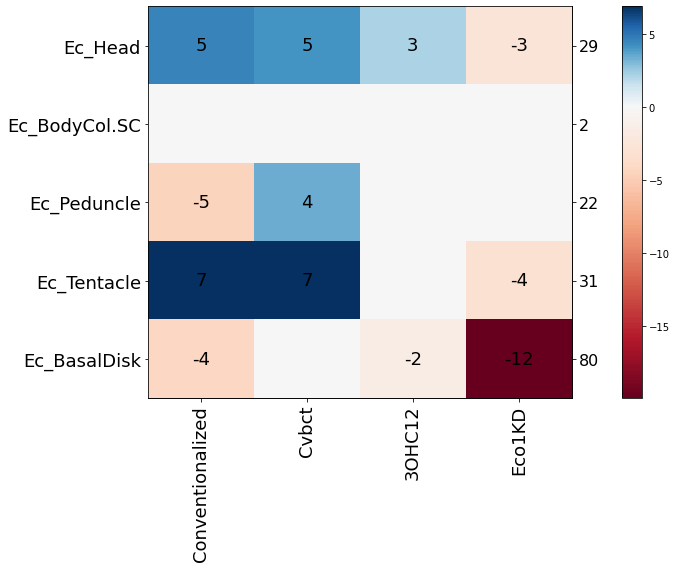

In [9]:
plot_heatmap_of_clusterings(ectoderm_statistic,ectoderm_pvalue,ectoderm_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments","ectoderm_ttest.jpg",
                           size=(10,8),fonts=18, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


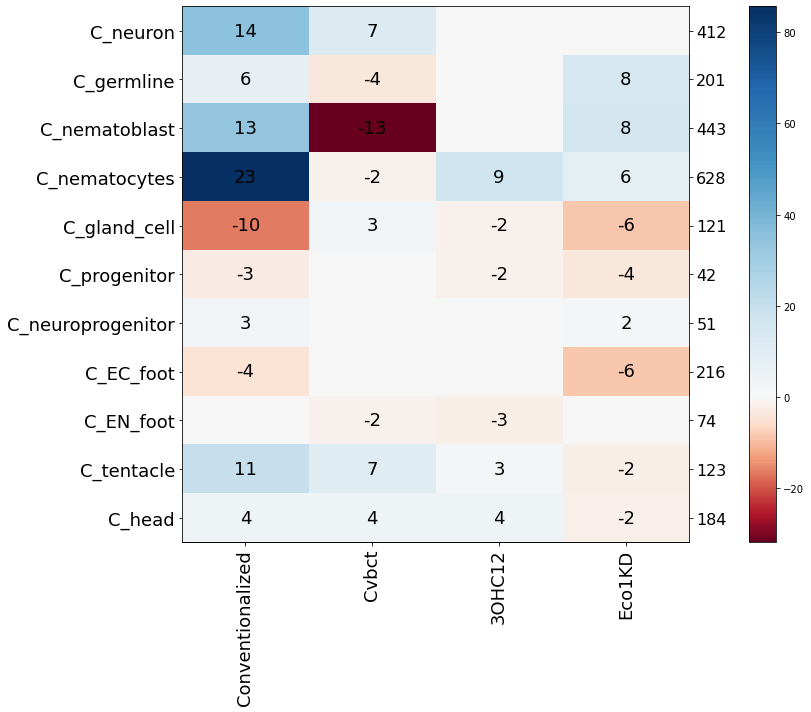

In [56]:
plot_heatmap_of_clusterings(supercluster_statistic,supercluster_pvalue,supercluster_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments","supercluster_ttest.jpg",
                           size=(12,10),fonts=18, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


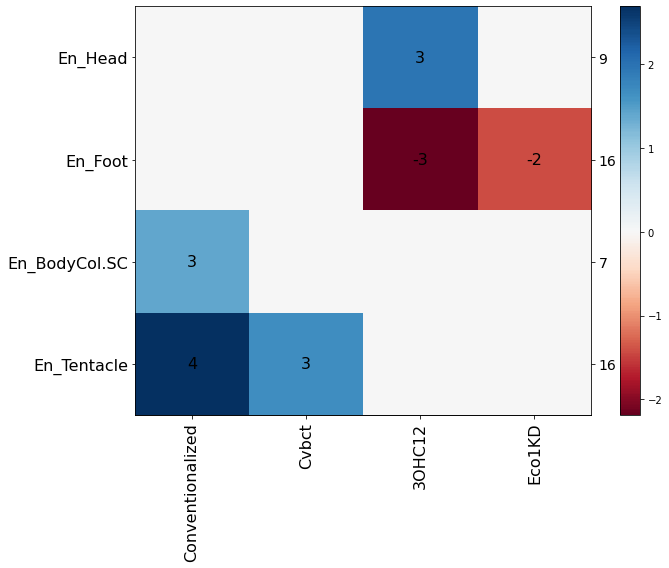

In [57]:
plot_heatmap_of_clusterings(endoderm_statistic,endoderm_pvalue,endoderm_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments","endoderm_ttest.jpg",
                           size=(10,8),fonts=16)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


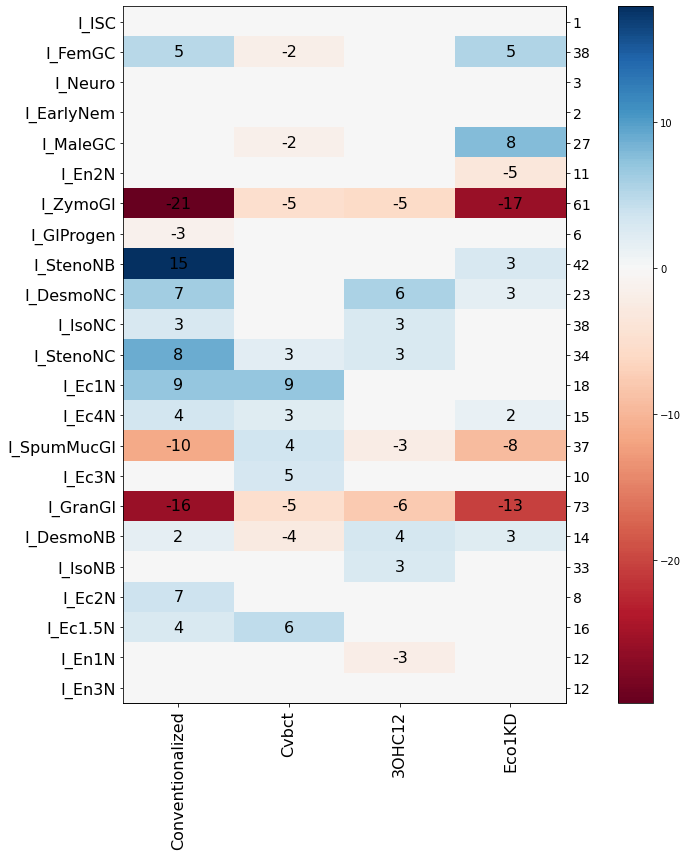

In [59]:
plot_heatmap_of_clusterings(interstitial_statistic,interstitial_pvalue,interstitial_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments","interstitial_ttest.jpg",
                           size=(10,12),fonts=16, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


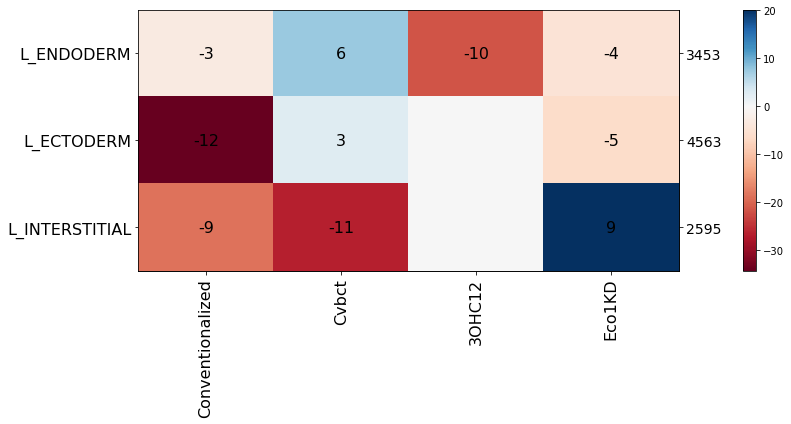

In [61]:
plot_heatmap_of_clusterings(l_supercluster_statistic,l_supercluster_pvalue,l_supercluster_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments","l_supercluster_ttest.jpg",
                           size=(12,6),fonts=16, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


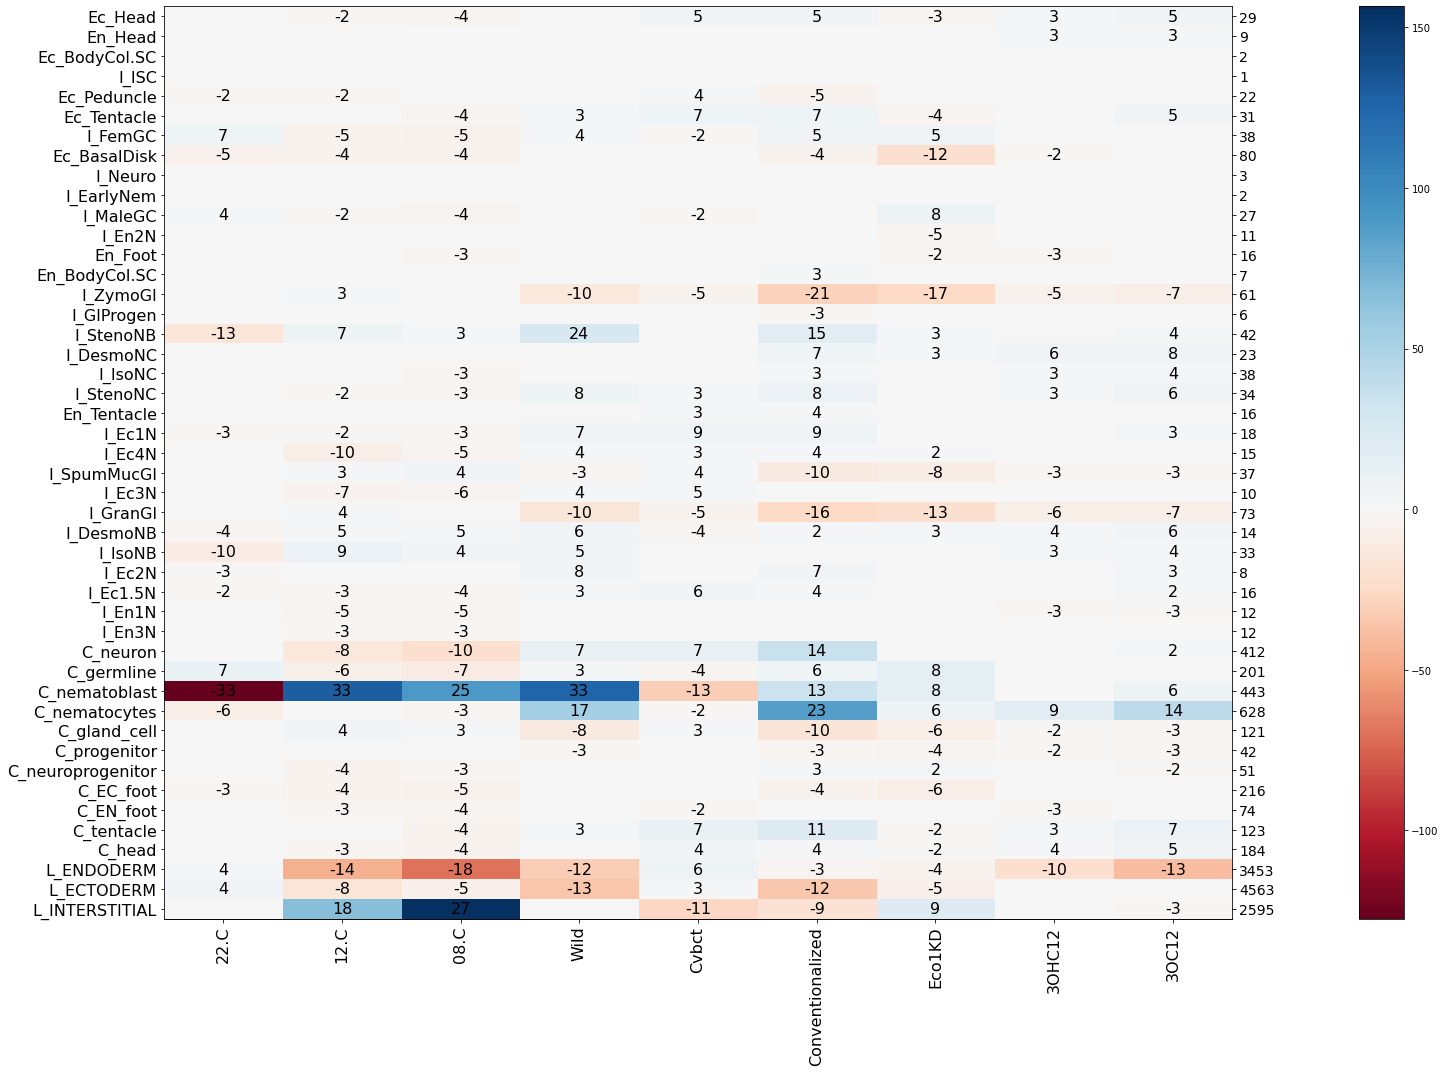

In [64]:
plot_heatmap_of_clusterings(statistic,pvalue,query_number,target_number,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments","test.jpg",
                           size=(22,15),fonts=16, padx=0.09)

In [13]:
pvalue

,22.C,12.C,08.C,Wild,Cvbct,Conventionalized,Eco1KD_B8,3OHC12,3OC12
L_ECTODERM,1.521441e-16,1.632853e-01,6.039335e-12,2.936294e-20,1.865617e-06,1.307452e-79,1.961571e-03,2.958692e-01,1.076703e-02
L_ENDODERM,1.323775e-15,2.347921e-03,1.282538e-03,9.064474e-15,5.596371e-03,1.401964e-29,1.127465e-02,1.574937e-23,2.532251e-56
C_nematoblast,1.765170e-93,2.485963e-117,9.596531e-107,8.618191e-104,1.340026e-32,1.359514e-19,1.375752e-20,5.974934e-01,7.309230e-04
I_StenoNB,3.075523e-113,1.335955e-101,3.504628e-66,2.756385e-142,3.134263e-20,3.501195e-59,1.206028e-08,4.347731e-05,3.487448e-02
I_IsoNB,1.940238e-96,7.312049e-100,1.034805e-74,3.586452e-99,5.847599e-22,1.840514e-20,2.206622e-11,1.560841e-01,1.482793e-04
L_INTERSTITIAL,2.860420e-08,1.945053e-97,1.199793e-195,1.771250e-03,2.362672e-53,6.901733e-52,1.880436e-19,7.745834e-01,5.974798e-09
I_DesmoNB,5.224233e-96,4.290714e-94,2.526858e-90,4.766389e-91,5.141811e-28,6.157249e-31,6.766036e-25,1.602298e-02,3.366495e-03
I_EarlyNem,1.049612e-16,2.319663e-25,1.335898e-31,5.616072e-32,6.613344e-15,1.134305e-07,2.870484e-09,1.032188e-05,6.396179e-02
I_ISC,6.632510e-04,1.108478e-11,8.303263e-12,5.289059e-09,5.895816e-06,1.006825e-01,2.918099e-07,2.999817e-01,9.703607e-02
C_neuroprogenitor,1.102522e-02,1.613771e-08,9.181171e-26,7.884373e-02,1.702032e-07,1.572314e-03,1.318858e-10,7.044163e-08,1.899887e-01


In [8]:
statistic = pd.read_table("../results/processedData/normalized_mean/ttest_all_statistic.table", delimiter=" ")
pvalue = pd.read_table("../results/processedData/normalized_mean/ttest_all_pvalue.table", delimiter=" ")
query_number = pd.read_table("../results/processedData/normalized_mean/ttest_all_query_number.table", delimiter=" ")
target_number = pd.read_table("../results/processedData/normalized_mean/ttest_all_target_number.table", delimiter=" ")

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


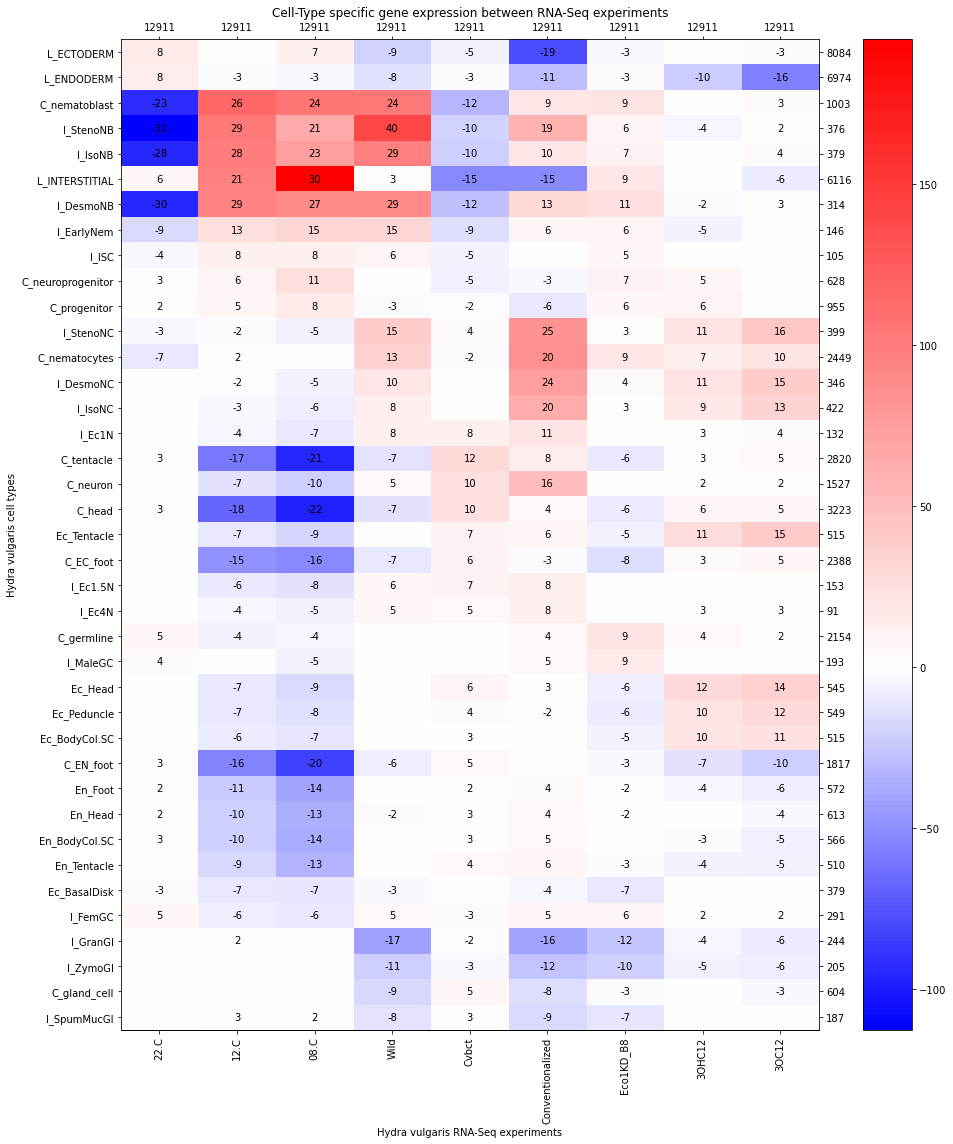

In [9]:
plot_heatmap_of_clusterings(statistic,pvalue,query_number,target_number,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments","test.jpg")

In [3]:
len(query_number)

15

In [4]:
pvalue.head()

,22.C,12.C,08.C,Wild,Cvbct,Conventionalized,Eco1KD_B8,3OHC12,3OC12
C_nematoblast,2.957751e-128,1.769396e-129,4.165713e-91,5.047402e-126,1.790037e-32,1.479320e-34,3.446547e-16,0.481337,2.985040e-08
I_StenoNB,6.168074e-16,3.258336e-09,1.335170e-02,3.552076e-26,3.338542e-01,1.279205e-18,1.255968e-03,0.351996,9.196127e-04
I_IsoNB,1.180162e-11,2.331454e-10,1.145336e-04,4.177366e-05,1.482617e-01,4.045949e-01,9.611090e-01,0.001997,2.192629e-04
C_germline,4.946983e-11,5.539191e-08,4.957716e-11,1.494306e-03,2.380159e-04,9.698621e-08,4.471533e-15,0.141123,2.031968e-01
L_INTERSTITIAL,3.711252e-01,6.042373e-68,3.150249e-157,1.329897e-01,1.936320e-27,2.424538e-19,7.927194e-21,0.065809,1.082390e-02


In [21]:
statistic.head()

,22.C,12.C,08.C,Wild,Cvbct,Conventionalized,Eco1KD_B8,3OHC12,3OC12
I_StenoNB,-32,29,21,40,-10,19,6,-4,2
I_IsoNB,-28,28,23,29,-10,10,7,-1,4
I_DesmoNB,-30,29,27,29,-12,13,11,-2,3
C_nematoblast,-23,26,24,24,-12,9,9,1,3
I_EarlyNem,-9,13,15,15,-9,6,6,-5,-2


In [8]:
# statistic dataframe holds the tvalues, "zero-out" tvalues with bad pvalue
for i in range(statistic.shape[0]):
    for j in range(statistic.shape[1]):
        if pvalue.iloc[i, j] > 0.05:
            statistic.iloc[i,j] = 0

In [10]:
# set the colormap and centre the colorbar
class MidpointNormalize(colors.Normalize):
    """Normalise the colorbar."""
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y), np.isnan(value))


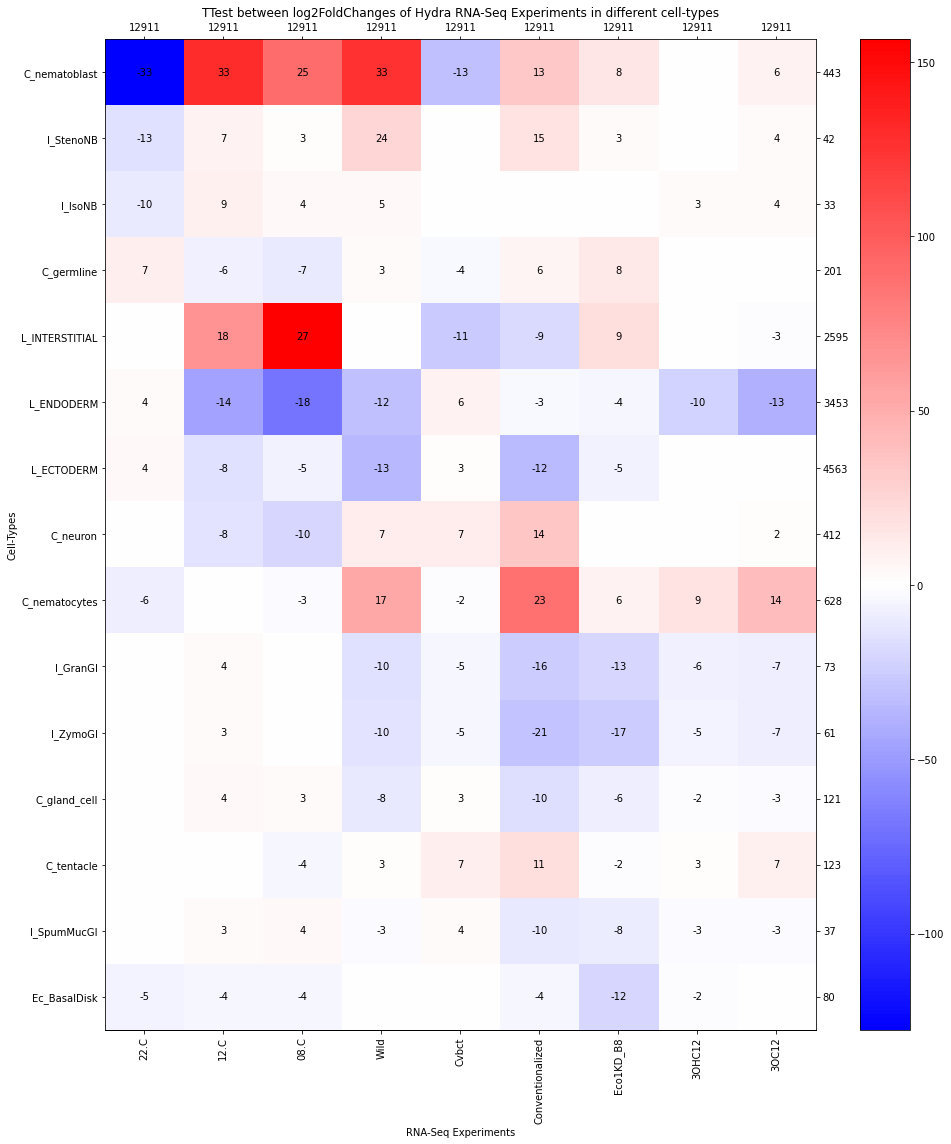

In [14]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(14,16))

cmap = "bwr"
pcolors = pd.DataFrame(abs(np.log10(pvalue)) * np.sign(statistic))
ax2 = ax.twinx()
ax3 = ax.twiny()
heatmap3 = ax3.imshow(pcolors, cmap=cmap, aspect='auto', norm=MidpointNormalize(min(pcolors.min()), max(pcolors.max()), 0.))
heatmap2 = ax2.imshow(pcolors, cmap=cmap, aspect='auto')
heatmap = ax.imshow(pcolors, cmap=cmap, aspect='auto')
cbar = plt.colorbar(heatmap3)

# Set x and y tick labels
xticklabels = statistic.columns
yticklabels = statistic.index
ax.set_yticks(np.arange(statistic.shape[0]))
ax.set_xticks(np.arange(statistic.shape[1]))
ax.set_xticklabels(xticklabels, rotation=90)
ax.set_yticklabels(yticklabels)

ax2.set_yticks(np.arange(statistic.shape[0]))
#ax2.set_xticks(np.arange(statistic.shape[1]))
#ax2.set_xticklabels(list(target_number.iloc[0,0:]))
ax2.set_yticklabels(query_number.V1)

#ax3.set_yticks(np.arange(statistic.shape[0]))
ax3.set_xticks(np.arange(statistic.shape[1]))
ax3.set_xticklabels(list(target_number.iloc[0,0:]))
#ax3.set_yticklabels(query_number.V1)
#ax2.invert_yaxis()
#ax.xaxis.tick_top()

# Loop over the data and add text annotations
for i in range(statistic.shape[0]):
    for j in range(statistic.shape[1]):
        if pvalue.iloc[i, j] < 0.05:
            ax3.text(j, i, f'{statistic.iloc[i, j]:.0f}', ha='center', va='center', color='black')
        else:
            ax3.text(j, i, '', ha='center', va='center', color='white')

# Set the title and labels
ax.set_title('TTest between log2FoldChanges of Hydra RNA-Seq Experiments in different cell-types')
ax.set_xlabel('RNA-Seq Experiments')
ax.set_ylabel('Cell-Types')

# Display the plot
#plt.show()
plt.tight_layout()
plt.savefig("test.jpg", dpi=500)